# Introduction

In this project, you will build a neural network of your own design to evaluate the CIFAR-10 dataset.
Our target accuracy is 70%, but any accuracy over 50% is a great start.
Some of the benchmark results on CIFAR-10 include:

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

Research with this dataset is ongoing. Notably, many of these networks are quite large and quite expensive to train. 

## Imports

In [1]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nnwhat
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

Specify your transforms as a list first.
The transforms module is already loaded as `transforms`.

CIFAR-10 is fortunately included in the torchvision module.
Then, you can create your dataset using the `CIFAR10` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/docs/stable/torchvision/datasets.html#cifar)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [2]:
# Define transforms
transform = transforms.Compose(
    [transforms.RandomRotation(15),
     transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Create training set and define training dataloader
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=5,
                                          shuffle=True, num_workers=2)

# Create test set and define test dataloader
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=5,
                                         shuffle=False, num_workers=2)

# The 10 classes in the dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [3]:
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])
    
        image = images[i].numpy()
        plt.imshow(image.T)
        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


frog


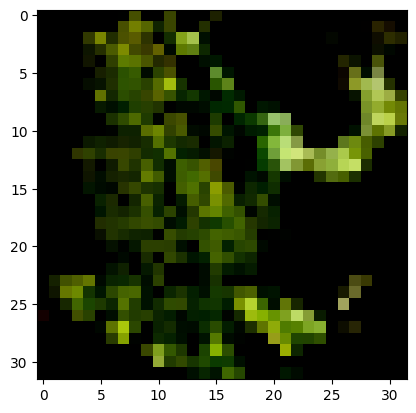

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


bird


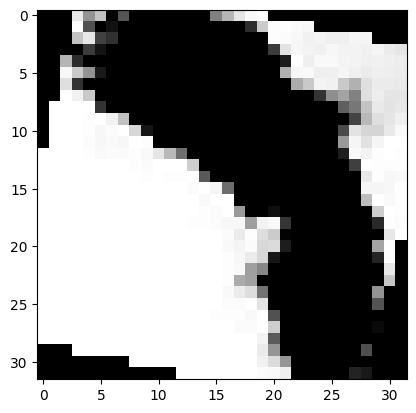

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


plane


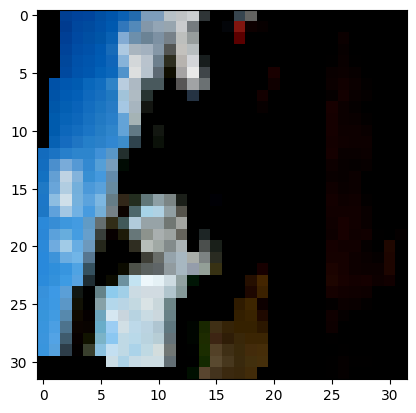

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


horse


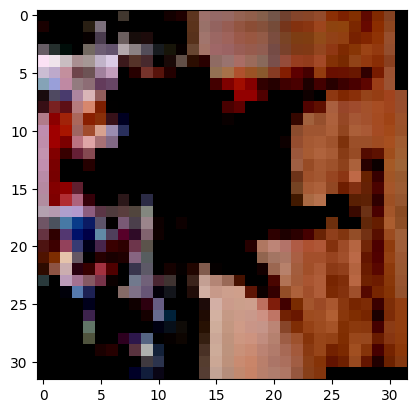

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


bird


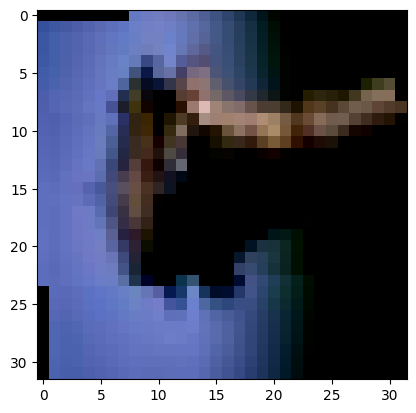

In [4]:
# Explore data
show5(trainloader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset. 
Feel free to construct a model of any architecture – feedforward, convolutional, or even something more advanced!

In [5]:
nn = nnwhat

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, len(classes))

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv2(x)))   # 16x16 -> 8x8
        x = self.pool(F.relu(self.conv3(x)))   # 8x8 -> 4x4
        x = self.dropout(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [6]:
# Instantiate the model
model = Net()

# Define loss function - CrossEntropyLoss is standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Define optimizer - Adam is a good choice with default learning rate
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss during each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [7]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model instantiated and moved to {device}")
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")

# train the model
num_epochs = 10
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_loss_sum = 0.0
    train_count = 0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = inputs.size(0)
        train_loss_sum += loss.item() * batch_size
        train_count += batch_size

        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f"Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 2000:.3f}")
            running_loss = 0.0

    # Per-epoch training loss
    epoch_train_loss = train_loss_sum / train_count
    train_losses.append(epoch_train_loss)

    # Validation loss and accuracy (using testloader as validation set in this notebook)
    model.eval()
    val_loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            batch_size = inputs.size(0)
            val_loss_sum += loss.item() * batch_size
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss_sum / total
    epoch_val_accuracy = 100.0 * correct / total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.2f}%"
    )

Model instantiated and moved to cuda
Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Epoch 1, Batch 2000, Loss: 1.855
Epoch 1, Batch 4000, Loss: 1.540
Epoch 1, Batch 6000, Loss: 1.443
Epoch 1, Batch 8000, Loss: 1.370
Epoch 1, Batch 10000, Loss: 1.325
Epoch 1/10 | Train Loss: 1.5068 | Val Loss: 1.2931 | Val Acc: 52.83%
Epoch 2, Batch 2000, Loss: 1.294
Epoch 2, Batch 4000, Loss: 1.279
Epoch 2, Batch 6000, Loss: 1.271
Epoch 2, Batch 8000, Loss: 1.249
Epoch 2, Batch 10000, Loss: 1.226
Epoch 2/10 | Train Loss: 1.2636 | Val Loss: 1.2114 | Val Acc: 57.37%
Epoch 3, Batch 2000, Loss: 1.187
Epoch 3, Batch 4000, Loss: 1.200
Epoch 3, Batch 6000, Loss: 1.172
Epoch 3, Batch 8000, Loss: 1.182
Epoch 3, Batch 10000, Loss: 1.166
Epoch 3/10 | Train Loss: 1.1816 | Val Loss: 1.0811 | Val Acc:

Plot the training loss (and validation loss/accuracy, if recorded).

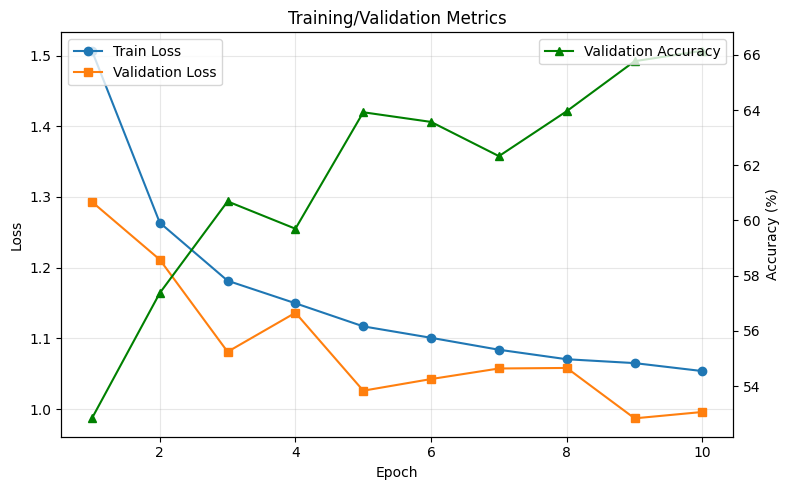

In [8]:
# Plot training loss + validation loss/accuracy
# If per-epoch history was not recorded during training, compute a single-point snapshot.

if "train_losses" not in globals() or len(train_losses) == 0:
    print("No per-epoch history found. Computing a current snapshot for train/validation metrics...")
    train_losses, val_losses, val_accuracies = [], [], []

    model.eval()

    # Train loss snapshot
    train_loss_sum, train_count = 0.0, 0
    with torch.no_grad():
        for x, y in trainloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss_val = criterion(logits, y)
            train_loss_sum += loss_val.item() * x.size(0)
            train_count += x.size(0)
    train_losses.append(train_loss_sum / train_count)

    # Validation loss + accuracy snapshot
    val_loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in testloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss_val = criterion(logits, y)
            val_loss_sum += loss_val.item() * x.size(0)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    val_losses.append(val_loss_sum / total)
    val_accuracies.append(100 * correct / total)

epochs = range(1, len(train_losses) + 1)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(epochs, train_losses, marker="o", label="Train Loss")
if "val_losses" in globals() and len(val_losses) == len(train_losses):
    ax1.plot(epochs, val_losses, marker="s", label="Validation Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper left")

if "val_accuracies" in globals() and len(val_accuracies) == len(train_losses):
    ax2 = ax1.twinx()
    ax2.plot(epochs, val_accuracies, color="green", marker="^", label="Validation Accuracy")
    ax2.set_ylabel("Accuracy (%)")
    ax2.legend(loc="upper right")

plt.title("Training/Validation Metrics")
plt.tight_layout()
plt.show()

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 70%, great work! 
This is a hard task to exceed 70% on.

If your accuracy is under 45%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [9]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in testloader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 65.92%


## Saving your model
Using `torch.save`, save your model for future loading.

In [10]:
# samve model for future loading/inference
torch.save(model.state_dict(), "cifar10_cnn.pth")
print("Model saved as cifar10_cnn.pth")

Model saved as cifar10_cnn.pth


## Make a Recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below.

I would recommend **building** a custom model for this problem. The training, validation, and testing results are reasonably close, which suggests the model is learning useful features and generalizing fairly well rather than severely overfitting. The training loss trends downward, the validation loss stays in a similar range, and the final test accuracy is about **65.927%**.

The training/validation/testing image supports that conclusion because the curves do not diverge dramatically: training loss is slightly lower than validation loss, but validation performance remains stable and the test accuracy is close to the validation accuracy. That means the model is consistent, but it is not yet strong enough to be considered a best-in-class solution.

So, if the goal is a tailored classifier for this dataset and you can continue improving the architecture, building is the better choice. If the requirement were much higher accuracy with minimal development time, buying or starting from a stronger pretrained solution would be more attractive.